# Deep Learning Model Selection

Three fully connected MLPs are built with **Keras** and compared:  
**Shallow** (1 hidden layer) · **Medium** (2 hidden layers) · **Deep** (3 hidden layers + BatchNorm + Dropout)

Modern Keras features: `Sequential` API · `EarlyStopping` · `ReduceLROnPlateau` · `AUC` metric.


## Setup


In [7]:
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import logging
from tensorflow.keras import layers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

warnings.filterwarnings("ignore")
logging.getLogger("absl").setLevel(logging.ERROR)
keras.utils.set_random_seed(42)

df = pd.read_csv("../data/ai_resume_screening.csv").drop(columns=["github_activity"])

X = df.drop("shortlisted", axis=1)
y = df["shortlisted"].map({"Yes": 1, "No": 0})

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

education_order = {"High School": 0, "Bachelors": 1, "Masters": 2, "PhD": 3}
X_train_enc = X_train.copy(); X_val_enc = X_val.copy(); X_test_enc = X_test.copy()
for split in [X_train_enc, X_val_enc, X_test_enc]:
    split["education_level"] = split["education_level"].map(education_order)

classes           = np.array([0, 1])
cw                = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {int(k): float(v) for k, v in zip(classes, cw)}

scaler      = StandardScaler()
X_train_s   = scaler.fit_transform(X_train_enc)
X_val_s     = scaler.transform(X_val_enc)
X_test_s    = scaler.transform(X_test_enc)

y_train_arr = y_train.values
y_val_arr   = y_val.values
y_test_arr  = y_test.values

n_features = X_train_s.shape[1]
print(f"Setup complete. n_features = {n_features}")
print(f"Train: {len(X_train_s)} | Val: {len(X_val_s)} | Test: {len(X_test_s)}")
print(f"Class weights: {class_weight_dict}")

Setup complete. n_features = 5
Train: 21000 | Val: 4500 | Test: 4500
Class weights: {0: 1.6603415559772297, 1: 0.7154538021259199}


## Model Architectures


In [8]:
def build_shallow(n):
    """5 → 8 → 1"""
    return keras.Sequential([
        layers.Input(shape=(n,)),
        layers.Dense(8, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ], name="shallow")

def build_medium(n):
    """5 → 16 → 8 → 1"""
    return keras.Sequential([
        layers.Input(shape=(n,)),
        layers.Dense(16, activation="relu"),
        layers.Dense(8, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ], name="medium")

def build_deep(n):
    """5 → 32 → BatchNorm → Dropout(0.3) → 16 → 8 → 1"""
    return keras.Sequential([
        layers.Input(shape=(n,)),
        layers.Dense(32, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(16, activation="relu"),
        layers.Dense(8, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ], name="deep")

shallow = build_shallow(n_features)
medium  = build_medium(n_features)
deep    = build_deep(n_features)

for m in [shallow, medium, deep]:
    m.summary()
    print()

Model: "shallow"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_9 (Dense)             (None, 8)                 48        
                                                                 
 dense_10 (Dense)            (None, 1)                 9         
                                                                 
Total params: 57
Trainable params: 57
Non-trainable params: 0
_________________________________________________________________

Model: "medium"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_11 (Dense)            (None, 16)                96        
                                                                 
 dense_12 (Dense)            (None, 8)                 136       
                                                                 
 dense_13 (Dense)            (None, 1)        

## Training

All models are compiled with Adam and `binary_crossentropy`.  
Class imbalance is addressed via `class_weight`.  
`EarlyStopping` halts training when `val_loss` stops improving and restores the best weights.  
`ReduceLROnPlateau` halves the learning rate when progress stalls.


In [9]:
def compile_and_train(model):
    model.compile(
        optimizer=keras.optimizers.legacy.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )
    return model.fit(
        X_train_s, y_train_arr,
        validation_data=(X_val_s, y_val_arr),
        epochs=100,
        batch_size=256,
        class_weight=class_weight_dict,
        callbacks=[
            callbacks.EarlyStopping(
                monitor="val_loss",
                patience=10,
                restore_best_weights=True,
                verbose=0,
            ),
            callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=5,
                min_lr=1e-6,
                verbose=0,
            ),
        ],
        verbose=0,
    )

histories = {}
for name, model in [("Shallow", shallow), ("Medium", medium), ("Deep", deep)]:
    print(f"Training {name}...", end=" ")
    hist = compile_and_train(model)
    histories[name] = hist
    epochs_run = len(hist.history["loss"])
    best_val   = min(hist.history["val_loss"])
    print(f"Done ({epochs_run} epochs, best val_loss={best_val:.4f})")

Training Shallow... Done (45 epochs, best val_loss=0.2397)
Training Medium... Done (39 epochs, best val_loss=0.2358)
Training Deep... Done (28 epochs, best val_loss=0.2373)


## Training Curves


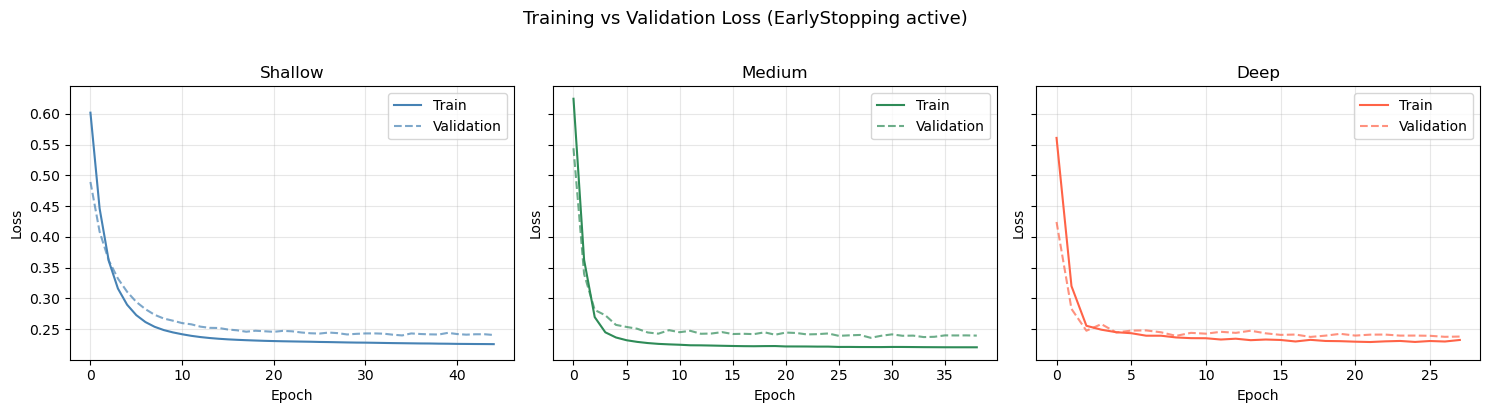

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
configs = [("Shallow", "steelblue"), ("Medium", "seagreen"), ("Deep", "tomato")]
for ax, (name, color) in zip(axes, configs):
    h = histories[name].history
    ax.plot(h["loss"],     label="Train",      color=color)
    ax.plot(h["val_loss"], label="Validation", color=color, linestyle="--", alpha=0.7)
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle("Training vs Validation Loss (EarlyStopping active)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Evaluation — Validation Set


In [11]:
for name, model in [("Shallow", shallow), ("Medium", medium), ("Deep", deep)]:
    preds = (model.predict(X_val_s, verbose=0).flatten() >= 0.5).astype(int)
    print(f"{name} — Validation Set")
    print(classification_report(y_val_arr, preds, target_names=["Not Shortlisted", "Shortlisted"]))

Shallow — Validation Set
                 precision    recall  f1-score   support

Not Shortlisted       0.77      0.91      0.83      1355
    Shortlisted       0.96      0.88      0.92      3145

       accuracy                           0.89      4500
      macro avg       0.86      0.90      0.88      4500
   weighted avg       0.90      0.89      0.89      4500

Medium — Validation Set
                 precision    recall  f1-score   support

Not Shortlisted       0.77      0.92      0.84      1355
    Shortlisted       0.96      0.88      0.92      3145

       accuracy                           0.89      4500
      macro avg       0.87      0.90      0.88      4500
   weighted avg       0.90      0.89      0.90      4500

Deep — Validation Set
                 precision    recall  f1-score   support

Not Shortlisted       0.77      0.91      0.84      1355
    Shortlisted       0.96      0.88      0.92      3145

       accuracy                           0.89      4500
      mac

## Comparison


In [12]:
rows = []
for name, model in [("Shallow", shallow), ("Medium", medium), ("Deep", deep)]:
    preds = (model.predict(X_val_s, verbose=0).flatten() >= 0.5).astype(int)
    rows.append({
        "Model":     name,
        "Precision": round(precision_score(y_val_arr, preds, zero_division=0), 4),
        "Recall":    round(recall_score(y_val_arr, preds), 4),
        "F1-Score":  round(f1_score(y_val_arr, preds), 4),
        "Accuracy":  round((preds == y_val_arr).mean(), 4),
    })
pd.DataFrame(rows).set_index("Model")

,Precision,Recall,F1-Score,Accuracy
Model,,,,
Shallow,0.9582,0.8827,0.9189,0.8911
Medium,0.9603,0.8843,0.9207,0.8936
Deep,0.9587,0.8849,0.9203,0.8929


## Final Test Set Evaluation


In [13]:
print("Medium Network — Test Set")
preds_test = (medium.predict(X_test_s, verbose=0).flatten() >= 0.5).astype(int)
print(classification_report(y_test_arr, preds_test, target_names=["Not Shortlisted", "Shortlisted"]))

Medium Network — Test Set
                 precision    recall  f1-score   support

Not Shortlisted       0.79      0.92      0.85      1355
    Shortlisted       0.96      0.89      0.93      3145

       accuracy                           0.90      4500
      macro avg       0.87      0.91      0.89      4500
   weighted avg       0.91      0.90      0.90      4500

